
# Prediccions amb un dataset de Futbol

https://huggingface.co/datasets/Damir81/football-charts-results-goal-timing

## Preparació de les dades

Aquest primer codi es manté per veure la transformació de les dades. No cal executar perquè ja està feta. 

In [ ]:
import pandas as pd
df = pd.read_csv("football_charts_matches.csv")

In [14]:
df.columns

Index(['league', 'league_name', 'country', 'season', 'match_date', 'time',
       'home_team', 'away_team', 'ht_result', 'ft_result', 'home_goals',
       'away_goals', 'total_goals', 'result', 'first_goal_time',
       'all_goal_times'],
      dtype='str')

In [15]:

dffiltered = df[["home_goals","away_goals","first_goal_time", "all_goal_times"]] 
dffiltered.head()

,home_goals,away_goals,first_goal_time,all_goal_times
0,2,0,47.0,"47,62"
1,1,0,41.0,41
2,1,0,61.0,61
3,0,1,44.0,44
4,4,0,11.0,"11,24,71,90"


In [19]:
goals_split = dffiltered['all_goal_times'].str.split(',')

for i in range(1, 5):
    goal_num = i + 1  # 2, 3, 4, 5
    dffiltered[f'goal_{goal_num}_time'] = goals_split.str[i]

In [28]:
dfnumeric = dffiltered.copy()

dfnumeric = dfnumeric.drop(columns=["all_goal_times"])

dfnumeric[["home_goals","away_goals","first_goal_time", "goal_2_time", "goal_3_time", "goal_4_time", "goal_5_time"]] = dffiltered[["home_goals","away_goals","first_goal_time", "goal_2_time", "goal_3_time", "goal_4_time", "goal_5_time"]].fillna(0).astype(int)

In [29]:
dfnumeric.head()

,home_goals,away_goals,first_goal_time,goal_2_time,goal_3_time,goal_4_time,goal_5_time
0,2,0,47,62,0,0,0
1,1,0,41,0,0,0,0
2,1,0,61,0,0,0,0
3,0,1,44,0,0,0,0
4,4,0,11,24,71,90,0


In [ ]:
dfnumeric.to_csv("football_charts_matches_numeric.csv", index=False)

## Anàlisi del problema 

En la fase previa s'han eliminat variables que no són interessants per a la regressió. Ens quedem sols amb les variables numèriques que considerem interessants. 

El que tenim és un dataset amb els gols de l'equip local i visitant i el minut al que es va marcar cada gol. Hem limitat a 5 gols perquè a partir de 6 ja no hi ha moltres mostres. 

In [1]:
import pandas as pd
df = pd.read_csv("football_charts_matches_numeric.csv")
df.head()

,home_goals,away_goals,first_goal_time,goal_2_time,goal_3_time,goal_4_time,goal_5_time
0,2,0,47,62,0,0,0
1,1,0,41,0,0,0,0
2,1,0,61,0,0,0,0
3,0,1,44,0,0,0,0
4,4,0,11,24,71,90,0


El histograma de les variables mostra una distribució desplaçada. És normal perquè hem posat a 0 quan no hi ha gols. En qualsevol cas, obviant la barra del 0, els segon, tercer i quant gol tenen una distribució quasi normal cada vegada més desplaçat cap a més minuts. 

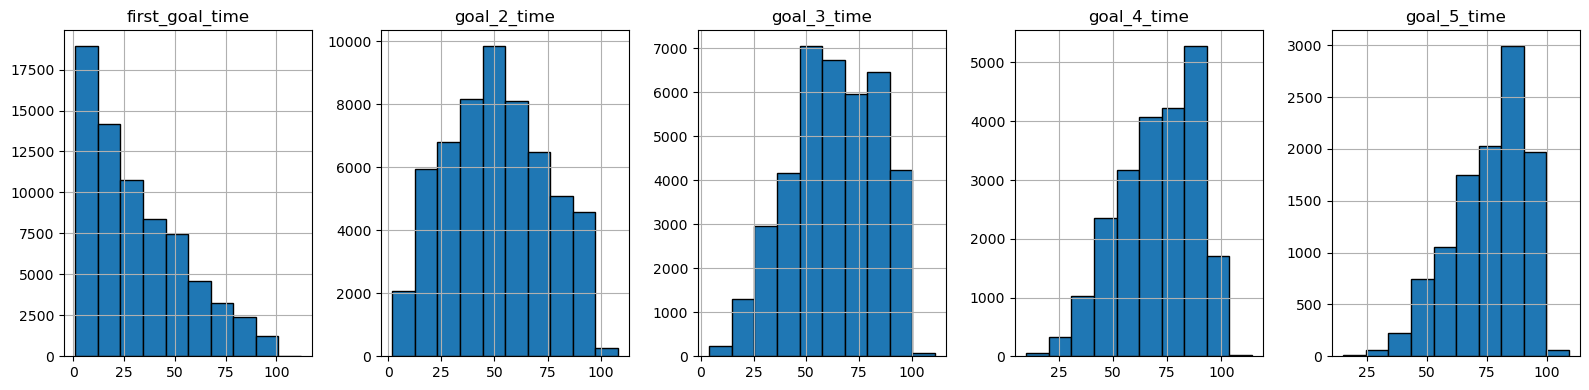

In [19]:
import numpy as np
import matplotlib.pyplot as plt

cols_gols = ["first_goal_time", "goal_2_time", "goal_3_time", "goal_4_time", "goal_5_time"]

# Usem np.nan en lloc de pd.NA per mantenir la columna com a numèrica (float)
df[cols_gols].replace(0, np.nan).hist(bins=10, figsize=(16, 4), layout=(1, 5), edgecolor='black')

plt.tight_layout()
plt.show()

Anem a analitzar les correlacions entre variables

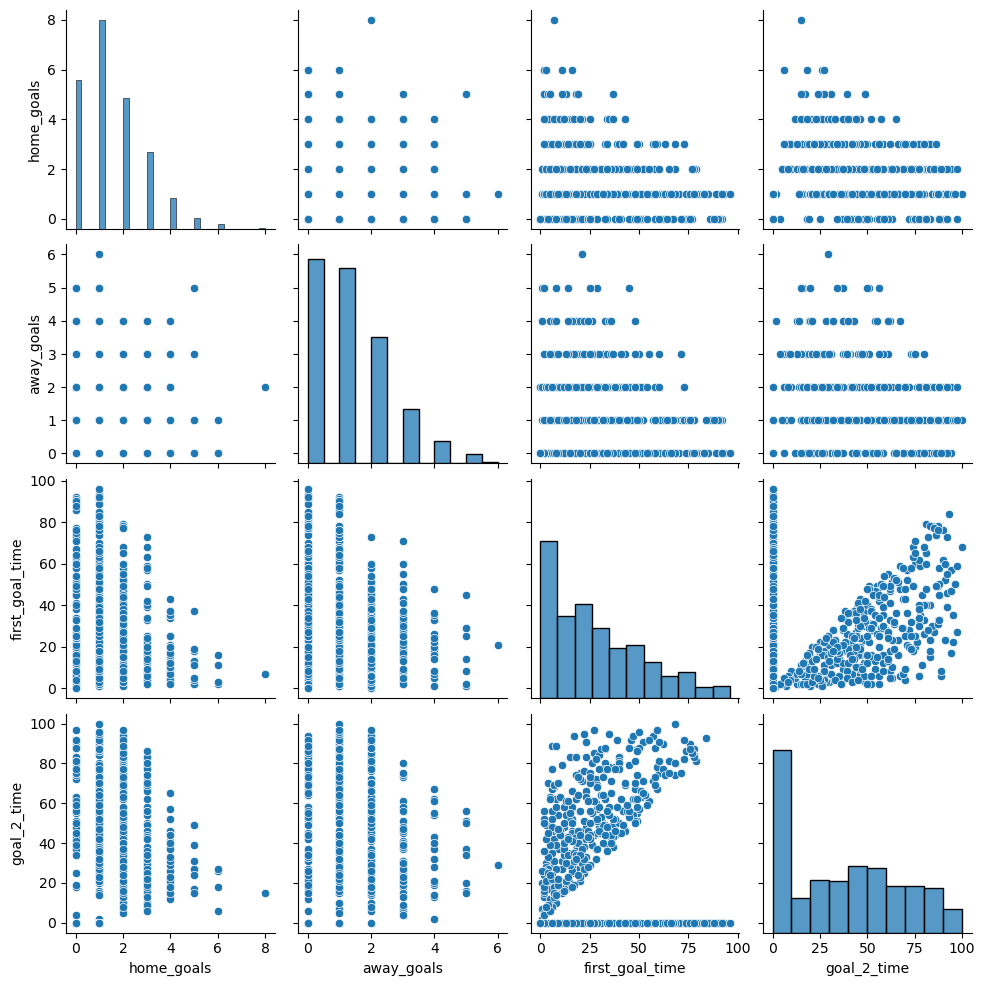

In [ ]:
import seaborn as sns
df_mostra = df.sample(n=500, random_state=42)[["home_goals","away_goals","first_goal_time", "goal_2_time"]]
sns.pairplot(data=df_mostra)

<Axes: >

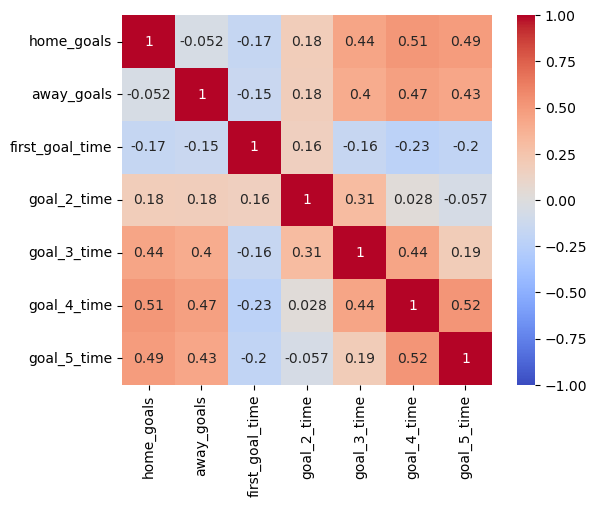

In [5]:
import seaborn as sns
corr_matrix = df.corr()

sns.heatmap(corr_matrix, square=True, annot=True, vmin=-1, vmax=1, cmap='coolwarm')

No tenen una correlació lineal (Pearson), encara que certa estructura es pot intuir a les gràfiques. Deguem buscar una manera més sofisticada de veure si les variables tenen alguna relació entre elles. Ho veurem quan separem el target. 

## Regressió per al quart gol

Per evitar `Data Leakage` no podem predir, per exemple, el primer gol amb el resultat final. Anem a suposar que estem fent una predicció de quant caurà el 4 gol siga de l'equip que siga mentre està jugant-se el partir. 

Les úniques dades vàlides, aleshores, són el primer, segon i tercer gol. Ho farem per al quart perquè hi ha més partits en 4 gols. 

> Planteja alguna predicció interessant que es podria fer també amb aquestes dades evitant el `Data leakage` 

Utilitzar valors nuls (`NaN`) reflecteix fidelment l'absència de dada però obliga a descartar files en models lineals, mentre que emprar valors sentinella (com `0` o `120`) evita perdre mostres però distorsiona greument la regressió lineal en introduir pesos matemàtics artificials que confonen la tendència (com equiparar un gol al minut zero amb una inexistència). Per solucionar aquest dilema de manera robusta, el **Hurdle Model** divideix el problema en dues fases seqüencials: primer utilitza un model de classificació per predir si el gol s'arribarà a marcar o no, i després aplica un model de regressió exclusivament sobre els casos positius per calcular el minut exacte, evitant qualsevol alteració matemàtica i resolent amb precisió tant l'ocurrència com el temps de l'esdeveniment.

Triar **Random Forest** per a la tasca de classificació és ideal perquè, a diferència dels models lineals, gestiona de manera natural relacions complexes i no lineals entre les variables, com ara combinar indicadors binaris i minuts de partit amb valors de farciment sense necessitat d'escalats complexos. En basar-se en un conjunt d'arbres de decisió que apliquen talls lògics seqüencials (com ara comprovar si el gol ha passat abans de tenir en compte el minut), l'algoritme processa sense problemes la presència de zeros o dades absents. A més, ofereix una gran robustesa davant el sobreajustament i un rendiment excel·lent des del primer moment, la qual cosa simplifica l'enginyeria de característiques en escenaris esportius tan irregulars.

S'ha de regularitzar el Random Forest per a evitar l'`OverFitting` amb dades tant caòtiques. 

> Pregunta a la IA si en aquest cas funcionaria bé una regressió lineal, SVR o KNN. 

In [6]:
df['has_goal_1'] = df['first_goal_time'] > 0
df['has_goal_2'] = df['goal_2_time'] > 0
df['has_goal_3'] = df['goal_3_time'] > 0
df['has_goal_4'] = df['goal_4_time'] > 0
df['has_goal_5'] = df['goal_5_time'] > 0

df.head()

,home_goals,away_goals,first_goal_time,goal_2_time,goal_3_time,goal_4_time,goal_5_time,has_goal_1,has_goal_2,has_goal_3,has_goal_4,has_goal_5
0,2,0,47,62,0,0,0,True,True,False,False,False
1,1,0,41,0,0,0,0,True,False,False,False,False
2,1,0,61,0,0,0,0,True,False,False,False,False
3,0,1,44,0,0,0,0,True,False,False,False,False
4,4,0,11,24,71,90,0,True,True,True,True,False


In [7]:

total_goles = df['home_goals'] + df['away_goals']
total_goles.value_counts().sort_index()

0      5791
1     13861
2     18221
3     16942
4     11353
5      6344
6      2832
7      1160
8       378
9       132
10       40
11       11
14        1
16        1
Name: count, dtype: int64

In [21]:
X = df[["first_goal_time", "goal_2_time", "goal_3_time", "has_goal_1", "has_goal_2", "has_goal_3"]]
y = df["goal_4_time"]



In [22]:
from sklearn.feature_selection import mutual_info_regression
import pandas as pd

mi_scores = mutual_info_regression(X, y)

# Ho ordenem en un DataFrame per veure-ho clar
df_mi = pd.DataFrame({'Variable': X.columns, 'Mutual_Information': mi_scores})
df_mi = df_mi.sort_values(by='Mutual_Information', ascending=False)

print(df_mi.head(10))

          Variable  Mutual_Information
2      goal_3_time            0.513508
1      goal_2_time            0.269598
5       has_goal_3            0.254466
0  first_goal_time            0.124394
4       has_goal_2            0.106252
3       has_goal_1            0.024737


Mutual information ens diu quan influeix una variable respecte al target. Queda clar que el tercer gol és el que més, junt al fet de tenir 3 gols i el temps del segon.

> Reflexiona el motiu de que el tems del 3er gol siga el més important. 

In [23]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_test_final = X_test.copy()
y_test_final = y_test.copy()

In [24]:
y_train

55295     0
34362     0
64948     0
4016     85
69744     0
         ..
6265      0
54886     0
76820     0
860       0
15795    63
Name: goal_4_time, Length: 61653, dtype: int64

In [25]:
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import confusion_matrix


# --- FASE 1: CLASSIFICACIÓ (Hi haurà 4t gol?) ---
# Creem un target binari: 1 si hi ha un valor vàlid, 0 si és NaN
y_class = (y_train > 0).astype(int)


clf_model = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_leaf=5, random_state=42)
clf_model.fit(X_train, y_class)


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap

In [26]:
import numpy as np

class_predictions = clf_model.predict(X_test)
print(np.unique(class_predictions, return_counts=True))
y_test_class = (y_test > 0).astype(int)
print(np.unique(y_test_class, return_counts=True))
conf_matrix = confusion_matrix(y_test_class, class_predictions)
conf_matrix

(array([0, 1]), array([10283,  5131]))
(array([0, 1]), array([10994,  4420]))


array([[9659, 1335],
       [ 624, 3796]])

La matriu de confusió respecte a les dades de test ens dona uns resultats raonablement bons. 

> Interpreta els resultats ens els termes de les mètriques estudiades en classe (Vertaders negatius, Falsos negatius...)

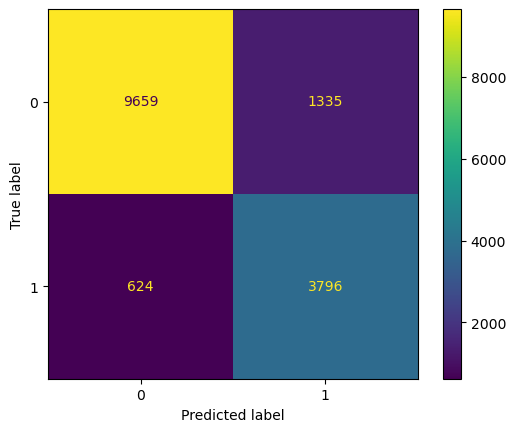

In [95]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(clf_model, X_test, y_test_class)

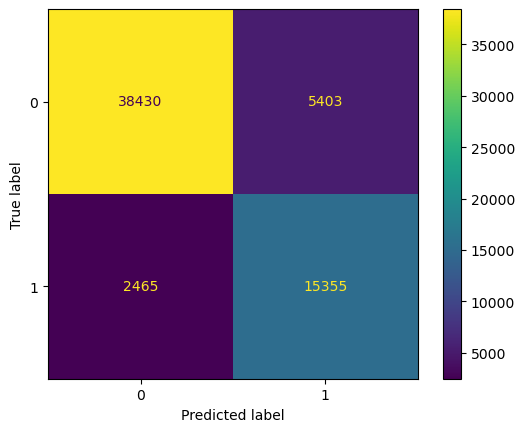

In [96]:
ConfusionMatrixDisplay.from_estimator(clf_model, X_train, y_class)

La matriu respecte a les dades d'entrenament està bé, però no és perfecta.

> Explica perquè no és una mala noticia que no siga perfecta. 

In [97]:

# --- FASE 2: REGRESSIÓ (A quin minut serà?) ---
# Filtrem el dataset per entrenar el regressor NOMÉS amb els casos on SÍ hi ha gol
mask_gols = df['goal_4_time'] > 0
X_reg = X[mask_gols]
y_reg = df.loc[mask_gols, 'goal_4_time']

X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

reg_model = RandomForestRegressor(n_estimators=100, max_depth=10, min_samples_leaf=5, random_state=42)
reg_model.fit(X_train, y_train)



,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of 

In [98]:
reg_predictions = reg_model.predict(X_test)
print(reg_model.score(X_test, y_test))

0.5322546169141089


Aquest és el `R2` del temps del 4t gol respecte als partits que tenen 4t gol. 

> Interpreta aquest R2 i digues si et sembla un bon resultat. 

In [99]:

# --- FASE 3: PREDICCIÓ COMBINADA (INFERÈNCIA) ---
# Per a un conjunt de dades nou (X_new):

#X_new, X_test, y_new, y_test = train_test_split(X, y, test_size=0.2, random_state=24)  # Exemple: utilitzem X_test com a nou conjunt de dades
y_test_final_class = (y_test_final > 0).astype(int)


pred_occurencia = clf_model.predict(X_test_final)      # Retorna 0 o 1
pred_minuts = reg_model.predict(X_test_final)          # Retorna el minut estimat

# Construïm la lògica final combinada
resultats_finals = np.where(pred_occurencia == 0, 0, pred_minuts)

In [100]:
print(pred_minuts[:10])  # Mostrem els primers 10 minuts predits
print(resultats_finals[:10])  # Mostrem els primers 10 resultats
print(y_test_final[:10].to_numpy())  # Mostrem els primers 10 valors reals
print(resultats_finals.shape, y_test_final.shape)

[40.38378178 40.38378178 72.97799497 96.81845832 58.32013878 35.62793161
 40.38378178 46.36086088 37.03096041 79.22072608]
[ 0.          0.         72.97799497  0.         58.32013878  0.
  0.          0.          0.         79.22072608]
[ 0  0 89  0  0  0  0  0  0 93]
(15414,) (15414,)


In [101]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test_final, resultats_finals)
r2 = r2_score(y_test_final, resultats_finals)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

# Filtrem només els casos on el test realment té gol i el model ha dit 1 (o mirem el subset real de gols)
mask_test_gols = (y_test_final > 0) & (pred_occurencia == 1)
mse_reg_pur = mean_squared_error(y_test_final[mask_test_gols], pred_minuts[mask_test_gols])
r2_reg_pur = r2_score(y_test_final[mask_test_gols], pred_minuts[mask_test_gols])

print(f"R2 del regressor pur (només gols encertats): {r2_reg_pur:.2f}")


Mean Squared Error (MSE): 846.94
R-squared (R2): 0.24
R2 del regressor pur (només gols encertats): 0.49


> Interpreta els resultats

## Regressió multi-output per al resultat final

El resultat final està dos variables: home_goals i away_goals. Es tracta de predir-les

Anem a quedar-nos amb els gols que estan marcats durant la primera part i després apostar pel resultat final mirant els minuts dels gols de la primera part. 

In [27]:
import pandas as pd
df = pd.read_csv("football_charts_matches_numeric.csv")

df['has_goal_1'] = df['first_goal_time'] > 0
df['has_goal_2'] = df['goal_2_time'] > 0
df['has_goal_3'] = df['goal_3_time'] > 0
df['has_goal_4'] = df['goal_4_time'] > 0
df['has_goal_5'] = df['goal_5_time'] > 0


df_results = df.copy()
df_results.head()

,home_goals,away_goals,first_goal_time,goal_2_time,goal_3_time,goal_4_time,goal_5_time,has_goal_1,has_goal_2,has_goal_3,has_goal_4,has_goal_5
0,2,0,47,62,0,0,0,True,True,False,False,False
1,1,0,41,0,0,0,0,True,False,False,False,False
2,1,0,61,0,0,0,0,True,False,False,False,False
3,0,1,44,0,0,0,0,True,False,False,False,False
4,4,0,11,24,71,90,0,True,True,True,True,False


In [28]:
df_results.loc[df_results['first_goal_time'] > 45, 'has_goal_1'] = False
df_results.loc[df_results['first_goal_time'] > 45, 'first_goal_time'] = 0 
df_results.loc[df_results['goal_2_time'] > 45, 'has_goal_2'] = False
df_results.loc[df_results['goal_2_time'] > 45, 'goal_2_time'] = 0 
df_results.loc[df_results['goal_3_time'] > 45, 'has_goal_3'] = False
df_results.loc[df_results['goal_3_time'] > 45, 'goal_3_time'] = 0 
df_results.loc[df_results['goal_4_time'] > 45, 'has_goal_4'] = False
df_results.loc[df_results['goal_4_time'] > 45, 'goal_4_time'] = 0 
df_results.loc[df_results['goal_5_time'] > 45, 'has_goal_5'] = False
df_results.loc[df_results['goal_5_time'] > 45, 'goal_5_time'] = 0 

df_results.head()

,home_goals,away_goals,first_goal_time,goal_2_time,goal_3_time,goal_4_time,goal_5_time,has_goal_1,has_goal_2,has_goal_3,has_goal_4,has_goal_5
0,2,0,0,0,0,0,0,False,False,False,False,False
1,1,0,41,0,0,0,0,True,False,False,False,False
2,1,0,0,0,0,0,0,False,False,False,False,False
3,0,1,44,0,0,0,0,True,False,False,False,False
4,4,0,11,24,0,0,0,True,True,False,False,False


In [29]:
X = df_results[["first_goal_time", "goal_2_time", "goal_3_time", "has_goal_1", "has_goal_2", "has_goal_3", "has_goal_4", "has_goal_5", "goal_4_time", "goal_5_time"]]
y = df_results[["home_goals", "away_goals"]] 


In [31]:
from sklearn.feature_selection import mutual_info_regression
import pandas as pd

mi_scores = mutual_info_regression(X, y["home_goals"])  # Mutual information for home goals

# Ho ordenem en un DataFrame per veure-ho clar
df_mi = pd.DataFrame({'Variable': X.columns, 'Mutual_Information': mi_scores})
df_mi = df_mi.sort_values(by='Mutual_Information', ascending=False)

print(df_mi.head(10))

          Variable  Mutual_Information
0  first_goal_time            0.101333
3       has_goal_1            0.090468
4       has_goal_2            0.086522
1      goal_2_time            0.086417
5       has_goal_3            0.059205
2      goal_3_time            0.052678
6       has_goal_4            0.024256
8      goal_4_time            0.022367
9      goal_5_time            0.008319
7       has_goal_5            0.006513


> Fes el mateix per a away_goals i compara els resultats. 

> Interpreta els resultats. Amb aquesta mutual information podem fer un model que funcione?

Els Random Forest tenen la capacitat de donar més d'una regressió. 

In [5]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import confusion_matrix

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


reg_model = RandomForestRegressor(n_estimators=100, max_depth=10, min_samples_leaf=5, random_state=42)
reg_model.fit(X_train, y_train)



,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of 

In [15]:
print(f"R2 del model: {reg_model.score(X_test, y_test):.2f}")

from sklearn.metrics import r2_score

y_pred = reg_model.predict(X_test)
# Obté l'R² de cada variable per separat (retorna un array amb dos valors)
r2_per_target = r2_score(y_test, y_pred, multioutput='raw_values')

print(f"R2 per a gols de casa: {r2_per_target[0]:.2f}")
print(f"R2 per a gols de fora: {r2_per_target[1]:.2f}")

import numpy as np

# 1. Arrodonir les prediccions a enters
y_pred_rounded = np.round(y_pred).astype(int)

# Assegurar-nos que y_test sigui un array de NumPy
y_test_np = y_test.to_numpy() if hasattr(y_test, 'to_numpy') else y_test

# 2. Comprovar on coincideixen EXACTAMENT la casa i la fora a la vegada
exact_matches = (y_pred_rounded[:, 0] == y_test_np[:, 0]) & (y_pred_rounded[:, 1] == y_test_np[:, 1])

# 3. Calcular el percentatge
accuracy_exacta = np.mean(exact_matches) * 100
print(f"Percentatge de marcadors exactes encertats: {accuracy_exacta:.2f}%")


R2 del model: 0.21
R2 per a gols de casa: 0.24
R2 per a gols de fora: 0.18
Percentatge de marcadors exactes encertats: 12.85%


> Interpreta els resultats. Un encert total com aquest és un bon resultat amb l'informació de la primera part?

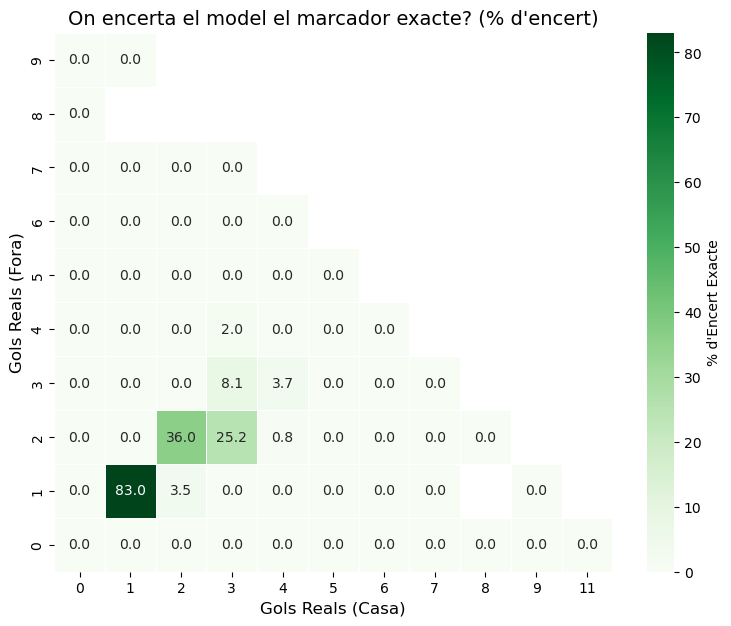

In [16]:
import pandas as pd

# Creem un DataFrame amb els resultats reals i si s'ha encertat exactament o no (True/False)
df_exactes = pd.DataFrame({
    'Real_Casa': y_test_np[:, 0],
    'Real_Fora': y_test_np[:, 1],
    'Encertat_Exacte': exact_matches
})

# Taula pivot per veure la proporció d'encerts per cada resultat real
pivot_encerts = df_exactes.pivot_table(
    values='Encertat_Exacte',
    index='Real_Fora',
    columns='Real_Casa',
    aggfunc='mean'  # Donarà la proporció d'encerts (de 0.0 a 1.0) per a cada marcador
) * 100 # Ho passem a percentatge

# Pintem el mapa de calor d'encerts exactes
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 7))
sns.heatmap(pivot_encerts, 
            annot=True,          
            fmt='.1f',           # Un decimal amb el percentatge
            cmap='Greens',       # Verd (on més verd, més s'encerta aquest resultat)
            cbar_kws={'label': '% d\'Encert Exacte'},
            linewidths=0.5,      
            linecolor='white'
)

plt.xlabel('Gols Reals (Casa)', fontsize=12)
plt.ylabel('Gols Reals (Fora)', fontsize=12)
plt.title('On encerta el model el marcador exacte? (% d\'encert)', fontsize=14)
plt.gca().invert_yaxis()
plt.show()

> Clarament la predicció del 1-1 és la millor. Explica els motius. 

In [7]:
type(y_test), type(y_pred)

(pandas.DataFrame, numpy.ndarray)

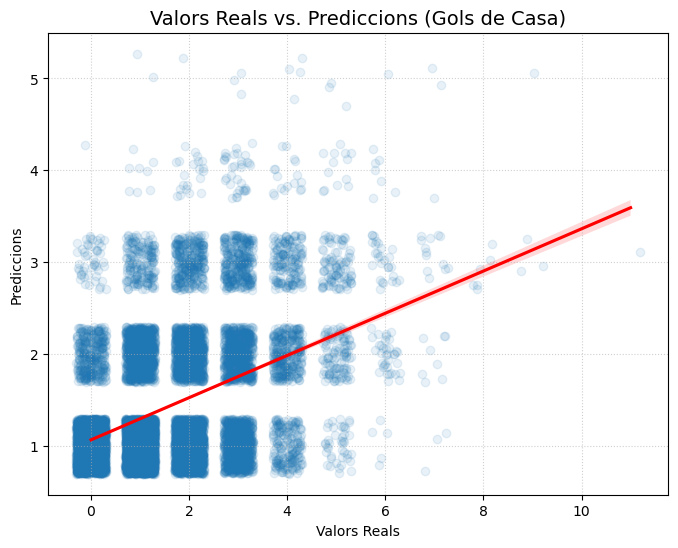

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(8, 6))

y_pred_rounded = np.round(y_pred)

# Usem .iloc[:, 0] per accedir a la primera columna
sns.regplot(x=y_test.iloc[:, 0], 
            y=y_pred_rounded[:, 0], 
            scatter_kws={'alpha': 0.1}, 
            line_kws={'color': 'red'},
            x_jitter=0.3,  # Dispersió horitzontal
            y_jitter=0.3   # Dispersió vertical
           )
plt.title('Valors Reals vs. Prediccions (Gols de Casa)', fontsize=14)
plt.xlabel('Valors Reals')
plt.ylabel('Prediccions')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

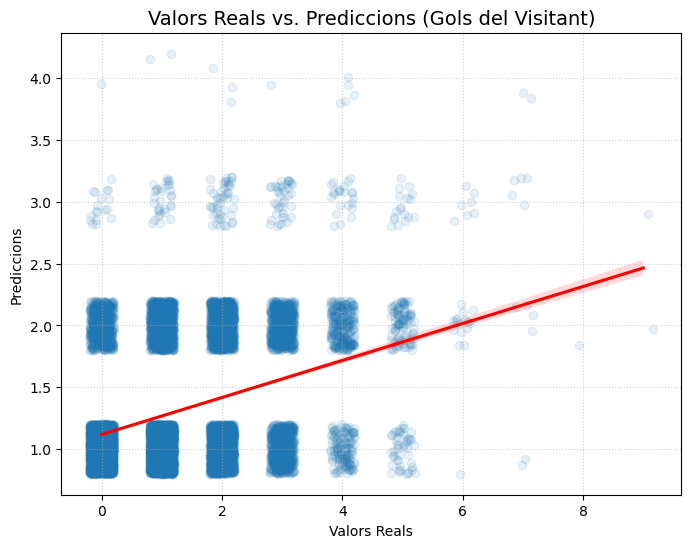

In [11]:
plt.figure(figsize=(8, 6))

# Usem .iloc[:, 1] per accedir a la segona columna
sns.regplot(x=y_test.iloc[:, 1], 
            y=y_pred_rounded[:, 1], 
            scatter_kws={'alpha': 0.1}, 
            line_kws={'color': 'red'},
            x_jitter=0.2,  # Dispersió horitzontal
            y_jitter=0.2   # Dispersió vertical
           )
plt.title('Valors Reals vs. Prediccions (Gols del Visitant)', fontsize=14)
plt.xlabel('Valors Reals')
plt.ylabel('Prediccions')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

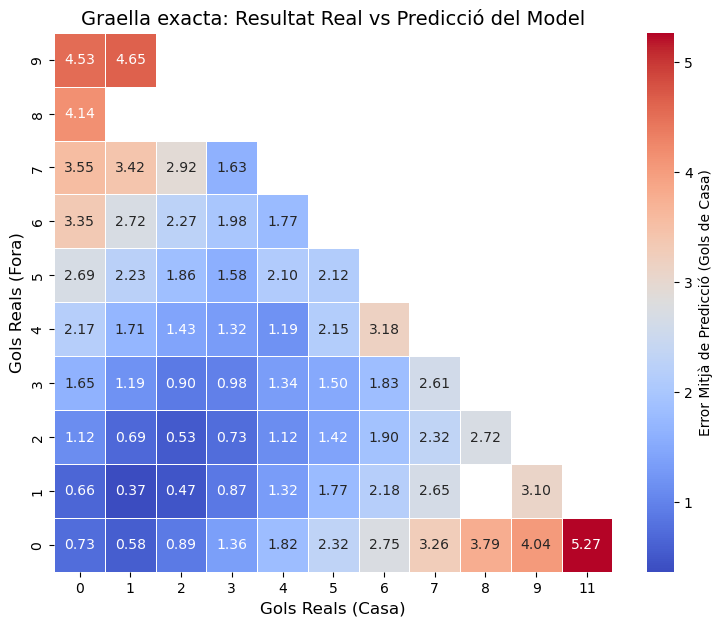

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Calculem l'error absolut mitjà per partit (mitjana de l'error en casa i l'error fora)
error_casa = np.abs(y_test.iloc[:, 0] - y_pred[:, 0])
error_fora = np.abs(y_test.iloc[:, 1] - y_pred[:, 1])
error_mitja_partit = (error_casa + error_fora) / 2

df_res = pd.DataFrame({
    'Real_Casa': y_test.iloc[:, 0],
    'Real_Fora': y_test.iloc[:, 1],
    'Pred_Casa': y_pred[:, 0],
    'Error_mitja': error_mitja_partit,
})

# Fem una taula pivot per calcular l'error mitjà del model per a cada combinació exacta de gols reals
pivot_pred = df_res.pivot_table(
    values='Error_mitja',
    index='Real_Fora',
    columns='Real_Casa',
    aggfunc='mean'
)

plt.figure(figsize=(9, 7))

# Dibuixem el mapa de calor on cada cel·la és un nombre enter exacte
sns.heatmap(pivot_pred, 
            annot=True,          # Mostra el valor numèric dins de la cel·la
            fmt='.2f',           # Format de dos decimals
            cmap='coolwarm',     # Paleta de colors
            cbar_kws={'label': 'Error Mitjà de Predicció (Gols de Casa)'},  # Etiqueta de la barra de color
            linewidths=0.5,      # Línies separadores entre cel·les
            linecolor='white'
)

plt.xlabel('Gols Reals (Casa)', fontsize=12)
plt.ylabel('Gols Reals (Fora)', fontsize=12)
plt.title('Graella exacta: Resultat Real vs Predicció del Model', fontsize=14)

# Invertim l'eix Y perquè el 0 de fora quedi a baix a l'esquerra (com un pla cartesià clàssic)
plt.gca().invert_yaxis()

plt.show()

> Escriu unes conclusions i proposa què es podria fer en tot el procés de machine learning per millorar els resultats. 